<a href="https://colab.research.google.com/github/franov/analytics/blob/main/data_science_and_ia/Clase_Google_Colab_vs_Anaconda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab vs. Anaconda: herramientas para ciencia de datos e IA

**Duración:** 3–4 horas  
**Enfoque:** IA y sistemas basados en conocimiento / modelos del mundo

---

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

1. Distinguir los escenarios donde Colab o Anaconda resultan más apropiados.
2. Gestionar entornos, dependencias y recursos (GPU/TPU) en ambas plataformas.
3. Implementar un flujo reproducible de ciencia de datos en Colab.
4. Entrenar un modelo de IA y evaluarlo con métricas robustas.
5. Construir un sistema híbrido que combine conocimiento simbólico con un modelo estadístico (**neuro-simbólico**).
6. Diseñar un *world model* simple y evaluar sus predicciones.

---

## Índice

- Parte 1. Fundamentos de Colab y comparación con Anaconda  
- Parte 2. Gestión de entornos y dependencias  
- Parte 3. Ejercicio 1 — Pipeline reproducible de datos  
- Parte 4. Ejercicio 2 — Clasificador con PyTorch (uso de GPU)  
- Parte 5. Ejercicio 3 — Sistema basado en conocimiento (neuro-simbólico)  
- Parte 6. Ejercicio 4 — Modelo del mundo simple (world model)  
- Parte 7. Cierre: cuándo usar Colab vs. Anaconda en investigación

# Parte 1. Fundamentos y comparación

## 1.1 ¿Qué es cada herramienta?

**Google Colab** es un servicio alojado por Google que ejecuta notebooks de Jupyter en máquinas virtuales efímeras, con acceso gratuito (limitado) a GPUs y TPUs. No requiere instalación local: el entorno se levanta bajo demanda y se destruye al cerrar la sesión.

**Anaconda** es una distribución de Python/R que se instala localmente. Incluye el gestor de paquetes `conda`, Jupyter Notebook/Lab, Spyder y más de 250 paquetes científicos preinstalados. El entorno es **persistente y bajo tu control total**.

## 1.2 Comparación rápida

| Dimensión | Google Colab | Anaconda |
|---|---|---|
| Instalación | Ninguna (navegador) | Local (~3 GB) |
| Hardware | GPU/TPU gratis (con cuotas) | El que tengas en tu máquina |
| Persistencia | Sesiones efímeras (~12 h) | Permanente |
| Gestor de paquetes | `pip` (conda es inusual) | `conda` + `pip` |
| Reproducibilidad | Requiere esfuerzo extra (requirements.txt, fijar versiones) | `environment.yml` + lockfiles |
| Datos grandes | Google Drive, GCS, descarga por red | Disco local, rápido |
| Offline | No | Sí |
| Colaboración | Nativa (estilo Docs) | Requiere Git / nbviewer |
| Privacidad | Los datos pasan por Google | Local, tú controlas |
| Costo | Free / Pro / Pro+ | Gratis (uso personal) |

## 1.3 Criterios de elección para investigación doctoral

- **Usa Colab cuando:** necesites GPU ocasional, quieras compartir experimentos rápidos con colegas/revisores, o prototipes modelos que no quepan en tu máquina.
- **Usa Anaconda cuando:** trabajes con datos sensibles/confidenciales, ejecutes experimentos largos (>12 h), requieras reproducibilidad estricta para una publicación, o dependas de librerías compiladas específicas.
- **Flujo híbrido (recomendado):** prototipo en Colab → refactorizas en local con Anaconda → lanzas experimentos largos en un servidor HPC o en la nube.


# Parte 2. Gestión de entornos y dependencias

## 2.1 En Colab

Cada notebook nuevo parte de una imagen preinstalada (Python, numpy, pandas, scikit-learn, torch, tensorflow, etc.). Para añadir un paquete:

```python
!pip install -q paquete==version
```

Verifica el entorno con las celdas de abajo.

In [1]:
# Diagnóstico del entorno
import sys, platform
print('Python:', sys.version.split()[0])
print('Plataforma:', platform.platform())

# Detectar si estamos en Colab
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
print('¿En Colab?:', EN_COLAB)

Python: 3.12.13
Plataforma: Linux-6.6.113+-x86_64-with-glibc2.35
¿En Colab?: True


In [2]:
# ¿Tenemos GPU disponible?
import subprocess
try:
    out = subprocess.check_output(['nvidia-smi'], text=True)
    print(out[:600])
except Exception as e:
    print('Sin GPU (o nvidia-smi no disponible):', e)

Sin GPU (o nvidia-smi no disponible): [Errno 2] No such file or directory: 'nvidia-smi'


> **Activar GPU en Colab:** `Entorno de ejecución → Cambiar tipo de entorno → Acelerador por hardware → GPU T4`.

## 2.2 En Anaconda

El equivalente reproducible se hace con un archivo `environment.yml`:

```yaml
name: phd-ia
channels: [conda-forge, pytorch, nvidia]
dependencies:
  - python=3.11
  - numpy
  - pandas
  - scikit-learn
  - jupyterlab
  - pytorch
  - pytorch-cuda=12.1
  - pip
  - pip:
      - transformers
      - networkx
```

Y luego:

```bash
conda env create -f environment.yml
conda activate phd-ia
```

> **Equivalencia Colab ↔ Anaconda:** genera un `requirements.txt` con `!pip freeze > requirements.txt` en Colab y llévalo al entorno local. Fija versiones siempre.

## 2.3 Montar Google Drive (solo Colab)

```python
from google.colab import drive
drive.mount('/content/drive')
# Ahora /content/drive/MyDrive/ es accesible como cualquier ruta.
```


# Parte 3. Ejercicio 1 — Pipeline reproducible de datos

**Objetivo:** construir un pipeline básico de EDA y preprocesamiento que funcione idéntico en Colab y Anaconda.

**Dataset:** Iris (de `sklearn`, para no depender de red).


In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Semilla global → pieza crítica de reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

iris = load_iris(as_frame=True)
df = iris.frame
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# EDA mínimo
print(df.describe().round(2))
print('\nDistribución de clases:')
print(df['target_name'].value_counts())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            150.00  150.00  
mean               1.20    1.00  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  

Distribución de clases:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: 

In [5]:
# Split estratificado + estandarización
X = df[iris.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train:', X_train_s.shape, 'Test:', X_test_s.shape)

Train: (112, 4) Test: (38, 4)


### 🔹 Ejercicio propuesto 1 (10 min)

Reemplaza Iris por el dataset **Wine** (`sklearn.datasets.load_wine`). Ajusta el pipeline y responde:

1. ¿Qué cambia en el número de clases y features?
2. ¿Sigue siendo apropiada la estratificación?
3. ¿Qué semilla usarías para un paper?

# Parte 4. Ejercicio 2 — Clasificador con PyTorch (GPU)

**Objetivo:** entrenar una red pequeña y observar la aceleración por GPU. Esto destaca una ventaja clara de Colab: acceso inmediato a hardware especializado.


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

# Semillas para reproducibilidad en torch
torch.manual_seed(RANDOM_STATE)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(RANDOM_STATE)

Dispositivo: cpu


In [7]:
# Tensores
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
Xte = torch.tensor(X_test_s, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=16, shuffle=True)

class MLP(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_out),
        )
    def forward(self, x):
        return self.net(x)

model = MLP(n_in=X_train_s.shape[1], n_hidden=32, n_out=3).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [8]:
# Entrenamiento
import time
EPOCHS = 100
hist = []
t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optim.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optim.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    hist.append(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | loss={epoch_loss:.4f}')
print(f'Tiempo total: {time.time()-t0:.2f}s en {device}')

Epoch  20 | loss=0.0487
Epoch  40 | loss=0.0424
Epoch  60 | loss=0.0092
Epoch  80 | loss=0.0031
Epoch 100 | loss=0.0013
Tiempo total: 3.92s en cpu


In [9]:
# Evaluación
from sklearn.metrics import classification_report, confusion_matrix
model.eval()
with torch.no_grad():
    preds = model(Xte.to(device)).argmax(dim=1).cpu().numpy()
print(classification_report(y_test, preds, target_names=iris.target_names))
print('Matriz de confusión:\n', confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38

Matriz de confusión:
 [[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]


### 🔹 Ejercicio propuesto 2 (15 min)

1. Duplica el número de neuronas por capa y compara el tiempo de entrenamiento en CPU vs GPU (usa `%%time`).
2. Añade `Dropout(0.2)` y reporta si mejora la métrica en test.
3. Guarda el modelo con `torch.save(model.state_dict(), 'model.pt')` y descárgalo con `google.colab.files.download(...)` (solo Colab).


# Parte 5. Ejercicio 3 — Sistema basado en conocimiento (neuro-simbólico)

**Motivación.** Los sistemas basados en conocimiento (KBS) codifican reglas explícitas sobre un dominio. Un enfoque moderno los combina con modelos estadísticos para obtener **IA neuro-simbólica**: inferencia interpretable + percepción robusta.

**Caso:** diagnóstico médico simplificado. Las reglas del dominio clasifican gravedad con criterios clínicos; la red usa las mismas features para predecir el riesgo. Comparamos y combinamos.


In [10]:
# Dataset sintético pero estructurado
rng = np.random.default_rng(RANDOM_STATE)
n = 500
edad = rng.integers(20, 85, size=n)
presion_sis = rng.normal(130, 20, size=n).clip(90, 200)
glucosa = rng.normal(110, 30, size=n).clip(70, 300)
imc = rng.normal(27, 5, size=n).clip(18, 45)

# Etiqueta "verdadera" generada por una regla con ruido
riesgo_real = (
    (presion_sis > 140).astype(int) +
    (glucosa > 125).astype(int) +
    (imc > 30).astype(int) +
    (edad > 60).astype(int)
)
# 0-1 = bajo, 2 = medio, 3-4 = alto
etiqueta = np.where(riesgo_real <= 1, 0, np.where(riesgo_real == 2, 1, 2))
# Añadimos 10% de ruido
mask = rng.random(n) < 0.10
etiqueta[mask] = rng.integers(0, 3, size=mask.sum())

df_med = pd.DataFrame({
    'edad': edad, 'presion_sis': presion_sis,
    'glucosa': glucosa, 'imc': imc, 'riesgo': etiqueta
})
df_med.head()

,edad,presion_sis,glucosa,imc,riesgo
0,25,128.114749,145.631753,21.993543,0
1,70,94.845432,79.381309,35.417931,1
2,62,100.659095,70.000000,24.345117,0
3,48,172.584942,112.971045,32.224364,1
4,48,104.251548,137.925147,27.339933,0


In [11]:
# 5.1 Componente SIMBÓLICO: motor de reglas
def clasificador_reglas(fila):
    """Reglas clínicas simplificadas. Devuelve 0=bajo, 1=medio, 2=alto.
    Estas reglas son inspeccionables, auditables y no requieren datos."""
    puntos = 0
    if fila['presion_sis'] > 140: puntos += 1
    if fila['glucosa']    > 125: puntos += 1
    if fila['imc']        > 30:  puntos += 1
    if fila['edad']       > 60:  puntos += 1
    if puntos <= 1: return 0
    if puntos == 2: return 1
    return 2

preds_simb = df_med.apply(clasificador_reglas, axis=1).values
acc_simb = (preds_simb == df_med['riesgo'].values).mean()
print(f'Accuracy del sistema de reglas: {acc_simb:.3f}')

Accuracy del sistema de reglas: 0.936


In [12]:
# 5.2 Componente NEURONAL: un clasificador aprendido
from sklearn.ensemble import GradientBoostingClassifier
feat = ['edad', 'presion_sis', 'glucosa', 'imc']
Xm = df_med[feat].values
ym = df_med['riesgo'].values
Xmtr, Xmte, ymtr, ymte = train_test_split(Xm, ym, test_size=0.25,
                                          stratify=ym, random_state=RANDOM_STATE)
clf = GradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xmtr, ymtr)
acc_neu = clf.score(Xmte, ymte)
print(f'Accuracy del modelo aprendido (test): {acc_neu:.3f}')

Accuracy del modelo aprendido (test): 0.888


In [13]:
# 5.3 Sistema HÍBRIDO: combinamos reglas + modelo con confianza
# Estrategia: si el modelo tiene alta confianza, lo usamos; si duda, confiamos en las reglas.
def predict_hibrido(row_df, modelo, umbral=0.75):
    proba = modelo.predict_proba(row_df[feat].values)
    conf = proba.max(axis=1)
    pred_neu = proba.argmax(axis=1)
    pred_sim = row_df.apply(clasificador_reglas, axis=1).values
    return np.where(conf >= umbral, pred_neu, pred_sim)

df_test = pd.DataFrame(Xmte, columns=feat)
preds_hib = predict_hibrido(df_test, clf, umbral=0.75)
acc_hib = (preds_hib == ymte).mean()
print(f'Accuracy del sistema híbrido: {acc_hib:.3f}')
print('\nResumen comparativo:')
print(f'  Reglas (simbólico):  {acc_simb:.3f}')
print(f'  Modelo (neural):     {acc_neu:.3f}')
print(f'  Híbrido (neuro-sim): {acc_hib:.3f}')

Accuracy del sistema híbrido: 0.912

Resumen comparativo:
  Reglas (simbólico):  0.936
  Modelo (neural):     0.888
  Híbrido (neuro-sim): 0.912


### 💡 Discusión

- El sistema de reglas es **interpretable** y funciona sin datos, pero frágil ante ruido.
- El modelo aprendido tolera ruido pero es una caja negra.
- El híbrido mantiene interpretabilidad en los casos dudosos y delega en el modelo cuando está seguro.

Este patrón es la base de arquitecturas neuro-simbólicas modernas (p. ej. *Logic Tensor Networks*, *Neural Theorem Provers*, y los trabajos de Garcez, Besold, d'Avila sobre integración).

### 🔹 Ejercicio propuesto 3 (20 min)

1. Añade una nueva regla clínica (p. ej. *sedentarismo* codificado como feature) y evalúa su impacto.
2. Estudia la sensibilidad al umbral: barre `umbral ∈ [0.5, 0.95]` y grafica la accuracy híbrida.
3. Representa las reglas como un grafo de conocimiento con `networkx` (nodos = factores; aristas = contribuciones al riesgo).

# Parte 6. Ejercicio 4 — Modelo del mundo (world model)

**Qué es un world model.** Un *modelo del mundo* es una representación interna que un agente aprende sobre su entorno para **predecir** cómo evoluciona el estado dadas las acciones. La literatura reciente (Ha & Schmidhuber 2018; Hafner et al. con *Dreamer*) muestra que aprender en *imaginación* sobre un world model mejora la eficiencia de muestra en RL.

**Versión didáctica.** Implementaremos un world model minimalista: un sistema dinámico tipo péndulo del que aprendemos la función de transición `(s, a) → s'` con una red neuronal. Luego comparamos la predicción del modelo vs. la dinámica real.


In [14]:
# Dinámica real (ground truth): péndulo con amortiguamiento + acción
# Estado s = (theta, theta_dot); acción a = torque escalar ∈ [-2, 2]
g, L, m, b, dt = 9.81, 1.0, 1.0, 0.1, 0.05

def paso_real(s, a):
    theta, omega = s[..., 0], s[..., 1]
    dtheta = omega
    domega = -(g / L) * np.sin(theta) - b * omega + a / (m * L**2)
    theta_next = theta + dt * dtheta
    omega_next = omega + dt * domega
    return np.stack([theta_next, omega_next], axis=-1)

# Generamos trayectorias con políticas aleatorias
rng = np.random.default_rng(RANDOM_STATE)
N_TRAY, T = 200, 120
S, A, Sn = [], [], []
for _ in range(N_TRAY):
    s = np.array([rng.uniform(-np.pi, np.pi), rng.uniform(-2, 2)])
    for _t in range(T):
        a = rng.uniform(-2, 2)
        sn = paso_real(s, a)
        S.append(s); A.append([a]); Sn.append(sn)
        s = sn
S  = np.asarray(S, dtype=np.float32)
A  = np.asarray(A, dtype=np.float32)
Sn = np.asarray(Sn, dtype=np.float32)
print('Dataset:', S.shape, A.shape, Sn.shape)

Dataset: (24000, 2) (24000, 1) (24000, 2)


In [15]:
# Modelo del mundo: red densa que predice el delta del estado
class WorldModel(nn.Module):
    def __init__(self, s_dim=2, a_dim=1, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + a_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, s_dim)
        )
    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        return s + self.net(x)  # predecimos el delta

wm = WorldModel().to(device)
opt = torch.optim.Adam(wm.parameters(), lr=1e-3)
Xt = torch.tensor(np.concatenate([S, A], axis=-1), device=device)
St = torch.tensor(S, device=device)
At = torch.tensor(A, device=device)
Snt = torch.tensor(Sn, device=device)

BATCH, EPOCHS = 512, 50
n = St.shape[0]
for ep in range(EPOCHS):
    idx = torch.randperm(n, device=device)
    total = 0.0
    for i in range(0, n, BATCH):
        j = idx[i:i+BATCH]
        pred = wm(St[j], At[j])
        loss = ((pred - Snt[j])**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * j.size(0)
    if (ep+1) % 10 == 0:
        print(f'Epoch {ep+1:2d} | MSE={total/n:.5f}')

Epoch 10 | MSE=0.01296
Epoch 20 | MSE=0.01063
Epoch 30 | MSE=0.00911
Epoch 40 | MSE=0.00846
Epoch 50 | MSE=0.00820


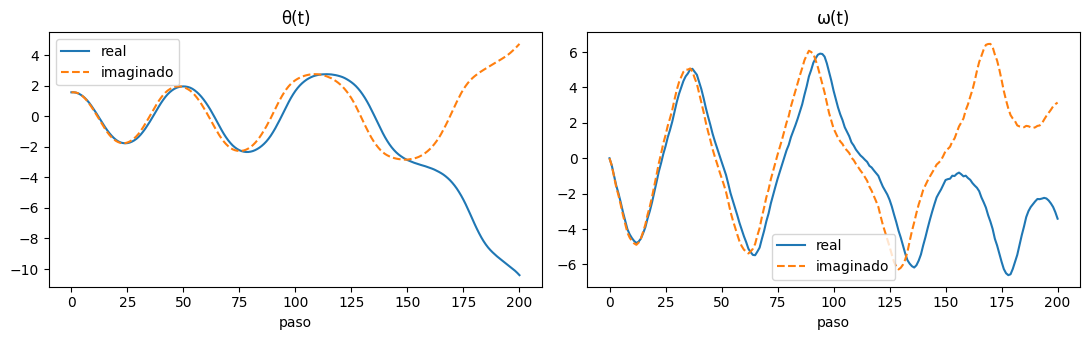

In [16]:
# Evaluación: rollout imaginario vs. real
import matplotlib.pyplot as plt

s_real = np.array([np.pi/2, 0.0], dtype=np.float32)
s_imag = s_real.copy()
traj_real, traj_imag = [s_real.copy()], [s_imag.copy()]
acciones = rng.uniform(-2, 2, size=200).astype(np.float32)

wm.eval()
with torch.no_grad():
    for a in acciones:
        s_real = paso_real(s_real, np.array([a], dtype=np.float32)[0])
        s_imag_t = wm(
            torch.tensor(s_imag[None], device=device),
            torch.tensor([[a]], device=device)
        ).cpu().numpy()[0]
        s_imag = s_imag_t
        traj_real.append(s_real.copy())
        traj_imag.append(s_imag.copy())

traj_real = np.array(traj_real)
traj_imag = np.array(traj_imag)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(traj_real[:,0], label='real'); ax[0].plot(traj_imag[:,0], label='imaginado', ls='--')
ax[0].set_title('θ(t)'); ax[0].legend(); ax[0].set_xlabel('paso')
ax[1].plot(traj_real[:,1], label='real'); ax[1].plot(traj_imag[:,1], label='imaginado', ls='--')
ax[1].set_title('ω(t)'); ax[1].legend(); ax[1].set_xlabel('paso')
plt.tight_layout(); plt.show()

### 💡 Discusión

- El modelo captura bien la dinámica a corto plazo, pero el error se acumula en horizontes largos (*compounding errors*). Es una limitación central de los world models.
- Técnicas para mitigarlo: modelos probabilísticos con estimación de incertidumbre, ensambles, arquitecturas recurrentes con estado latente (Dreamer, PlaNet).
- Un agente puede usar este modelo para **planificar** con *Model-Predictive Control* sin tocar el entorno real → ahorro brutal de muestras en RL.

### 🔹 Ejercicio propuesto 4 (25 min)

1. Reemplaza el MLP por un ensamble de 5 redes y reporta la media y desviación del rollout.
2. Define una función de costo `c(s, a) = θ² + 0.1·ω² + 0.01·a²` y usa *random shooting* (muestrear K secuencias de acciones, simular en el world model, elegir la mejor) para estabilizar el péndulo.
3. Compara la muestra eficiente vs. un baseline libre de modelo.

# Parte 7. ¿Cuándo usar Colab vs. Anaconda?

| Escenario de investigación | Recomendación |
|---|---|
| Prototipo rápido para un paper | Colab |
| Datos clínicos con IRB / privacidad | Anaconda local |
| Ajuste fino de un LLM con GPU | Colab Pro / servidor HPC |
| Experimentos que duran >12h | Anaconda + servidor |
| Material para clase / reproducible | Colab (link directo) |
| Tesis: experimentos finales | Anaconda + `environment.yml` + Git |

**Flujo recomendado para una tesis doctoral:**

1. Explora en Colab.
2. Migra a un repo Git con `environment.yml` y `requirements-lock.txt`.
3. Ejecuta experimentos largos en servidor, trackea con MLflow/Weights & Biases.
4. Publica notebooks Colab vinculados al repo para revisores.

## Lecturas recomendadas

- Ha, D. & Schmidhuber, J. (2018). *World Models*.
- Hafner, D. et al. (2023). *Mastering Diverse Domains through World Models (DreamerV3)*.
- Garcez, A. & Lamb, L. (2023). *Neurosymbolic AI: the 3rd wave*.
- Besold, T. R. et al. (2017). *Neural-Symbolic Learning and Reasoning: A Survey and Interpretation*.

---

**Fin del notebook.** Guarda una copia en tu Drive (`Archivo → Guardar una copia en Drive`) para continuar con los ejercicios propuestos.